# 실습 3: 쿼리 기반 정보 추출 (Queries)
**소요시간: 40분** | 난이도: ⭐⭐⭐

## 학습 목표
1. `analyze_document`의 `QUERIES` 기능으로 자연어 질문을 통해 문서에서 원하는 정보를 추출합니다.
2. QUERY → QUERY_RESULT Block 구조를 이해합니다.
3. 다양한 문서 유형에 맞는 쿼리를 설계합니다.

## API 개요: QUERIES 기능
```python
response = textract.analyze_document(
    Document={'Bytes': <바이트>},
    FeatureTypes=['QUERIES'],
    QueriesConfig={
        'Queries': [
            {'Text': 'What is the invoice number?', 'Alias': 'INVOICE_NUM'},
            {'Text': 'What is the total amount?',   'Alias': 'TOTAL'},
        ]
    }
)
```

### QUERY Block 구조
```
QUERY Block
├── Text: '질문 텍스트'
├── Query.Alias: '별칭'
└── Relationships[Type='ANSWER'] → QUERY_RESULT Block
                                     ├── Text: '답변 텍스트'
                                     └── Confidence: 신뢰도
```

### 💡 쿼리 작성 팁
- 영어 질문으로 작성하는 것이 정확도가 높습니다.
- 구체적인 질문일수록 좋습니다: `'What is the patient name?'` > `'Who?'`
- Alias는 결과 파싱 시 식별자로 활용됩니다.


/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


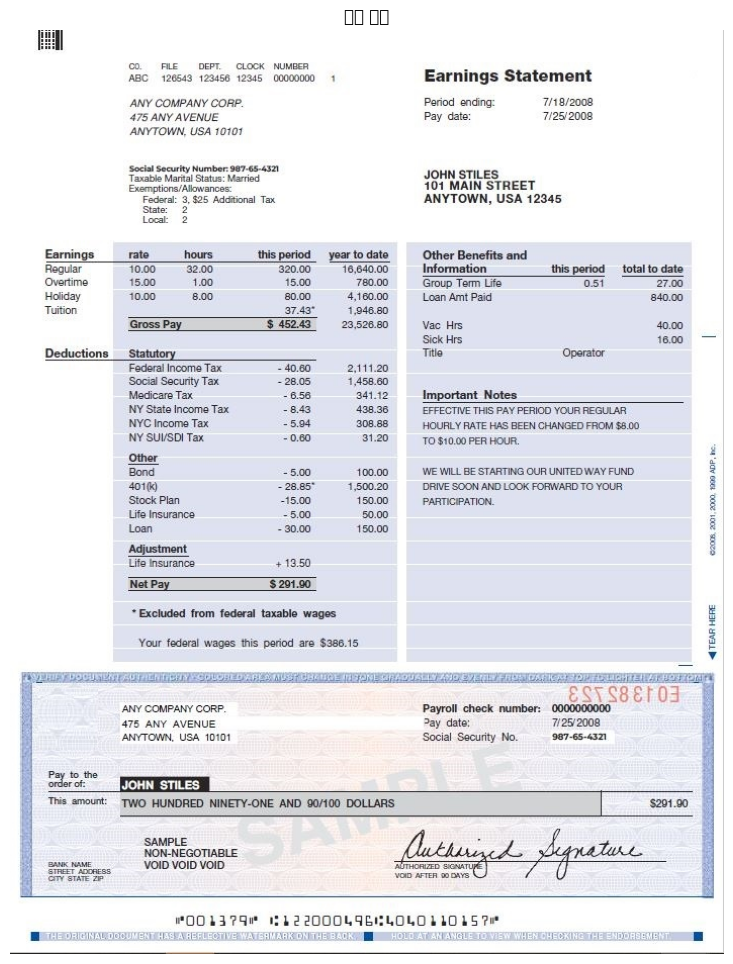

In [1]:
# ✅ [제공 코드]
import boto3, os
from PIL import Image
import matplotlib.pyplot as plt

textract = boto3.client('textract', region_name='ap-northeast-2')

IMAGE_DIR = './images/'
image_path = os.path.join(IMAGE_DIR, 'lab03_query.jpg')

def load_document_bytes(path):
    with open(path, 'rb') as f:
        return f.read()

doc_bytes = load_document_bytes(image_path)

img = Image.open(image_path)
plt.figure(figsize=(10, 12))
plt.imshow(img)
plt.axis('off')
plt.title('원본 문서')
plt.show()


## ✏️ TODO 1: 문서에 맞는 쿼리 설계

사용할 문서를 보고, 추출하고 싶은 정보를 쿼리로 작성하세요.

**예시 쿼리 (문서 유형별):**

| 문서 유형 | 쿼리 예시 |
|---|---|
| 계약서 | `'What is the contract date?'` |
| 이력서 | `'What is the applicant name?'`, `'What is the email address?'` |
| 의료 서식 | `'What is the patient name?'`, `'What is the date of birth?'` |
| 납품서 | `'What is the vendor name?'`, `'What is the delivery date?'` |


In [9]:
# ✏️ TODO 1: 문서에 맞는 쿼리를 정의하세요 (최소 3개 이상)
queries = [
    {
        'Text': 'What is the document date?',     # ← 첫 번째 질문 (예: 'What is the document date?')
        'Alias': 'DOCUMENT_DATE'     # ← 별칭 (예: 'DOCUMENT_DATE')
    },
    {
        'Text': 'What is the name?',     # ← 두 번째 질문 : 'What is the name?'
        'Alias': 'NAME'     # ← 별칭 (예: 'NAME')
    },
    {
        'Text': 'What is the reference number?',     # ← 세 번째 질문 : 'What is the reference number?'
        'Alias': 'REF_NUM'     # ← 별칭 (예: 'REF_NUM')
    },
    {
        'Text': 'How much is the net pay?',
        'Alias': 'NET_PAY'
    }
    # 필요하면 더 추가하세요
]

print(f"정의된 쿼리: {len(queries)}개")
for q in queries:
    print(f"  [{q['Alias']}] {q['Text']}")


정의된 쿼리: 4개
  [DOCUMENT_DATE] What is the document date?
  [NAME] What is the name?
  [REF_NUM] What is the reference number?
  [NET_PAY] How much is the net pay?


## ✏️ TODO 2: QUERIES 기능으로 API 호출


In [10]:
# ✏️ TODO 2: QUERIES 기능을 사용하여 API를 호출하세요
response = textract.analyze_document(
    Document={'Bytes': doc_bytes},
    FeatureTypes=['QUERIES'],                # ← 'QUERIES'
    QueriesConfig={
        'Queries' : queries                   # ← 'Queries' 
    }
)

blocks = response['Blocks']
block_map = {b['Id']: b for b in blocks}

# QUERY와 QUERY_RESULT 블록 수 확인
query_blocks  = [b for b in blocks if b['BlockType'] == 'QUERY']        # ← 'QUERY'
result_blocks = [b for b in blocks if b['BlockType'] == 'QUERY_RESULT']        # ← 'QUERY_RESULT'
print(f"QUERY 블록: {len(query_blocks)}개")
print(f"QUERY_RESULT 블록: {len(result_blocks)}개")


QUERY 블록: 4개
QUERY_RESULT 블록: 4개


## ✏️ TODO 3: 쿼리 결과 파싱

각 QUERY 블록에서 ANSWER 관계를 통해 QUERY_RESULT를 찾아 출력하세요.


In [11]:
# ✏️ TODO 3: 각 쿼리의 답변을 출력하세요
print("쿼리 결과:")
print("=" * 60)

results = {}  # Alias → 답변 저장

for qblock in query_blocks:
    alias = qblock.get('Query', {}).get('Alias',  'N/A')   # ← 'Alias'
    question = qblock.get('Query', {}).get('Text', 'N/A') # ← 'Text'
    answer = '(답변 없음)'
    confidence = 0
    
    # ANSWER 관계에서 QUERY_RESULT 블록 찾기
    for rel in qblock.get('Relationships', []):
        if rel['Type'] == 'ANSWER':                           # ← 'Type', 'ANSWER'
            for result_id in rel['Ids']:                  # ← 'Ids'
                result_block = block_map.get(result_id)
                if result_block:
                    answer = result_block.get('Text', '(빈값)')   # ← 'Text'
                    confidence = result_block.get('Confidence', 0)      # ← 'Confidence'
    
    results[alias] = {'question': question, 'answer': answer, 'confidence': confidence}
    print(f"  [{alias}]")
    print(f"    질문: {question}")
    print(f"    답변: {answer}")
    print(f"    신뢰도: {confidence:.1f}%")
    print()


쿼리 결과:
  [DOCUMENT_DATE]
    질문: What is the document date?
    답변: 7/25/2008
    신뢰도: 98.0%

  [NAME]
    질문: What is the name?
    답변: JOHN STILES
    신뢰도: 96.0%

  [REF_NUM]
    질문: What is the reference number?
    답변: 00000000
    신뢰도: 90.0%

  [NET_PAY]
    질문: How much is the net pay?
    답변: $291.90
    신뢰도: 93.0%



## ✏️ TODO 4: 답변 위치 시각화

QUERY_RESULT 블록의 위치를 이미지에 보라색으로 표시하고, 질문 내용을 레이블로 추가하세요.


/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/o

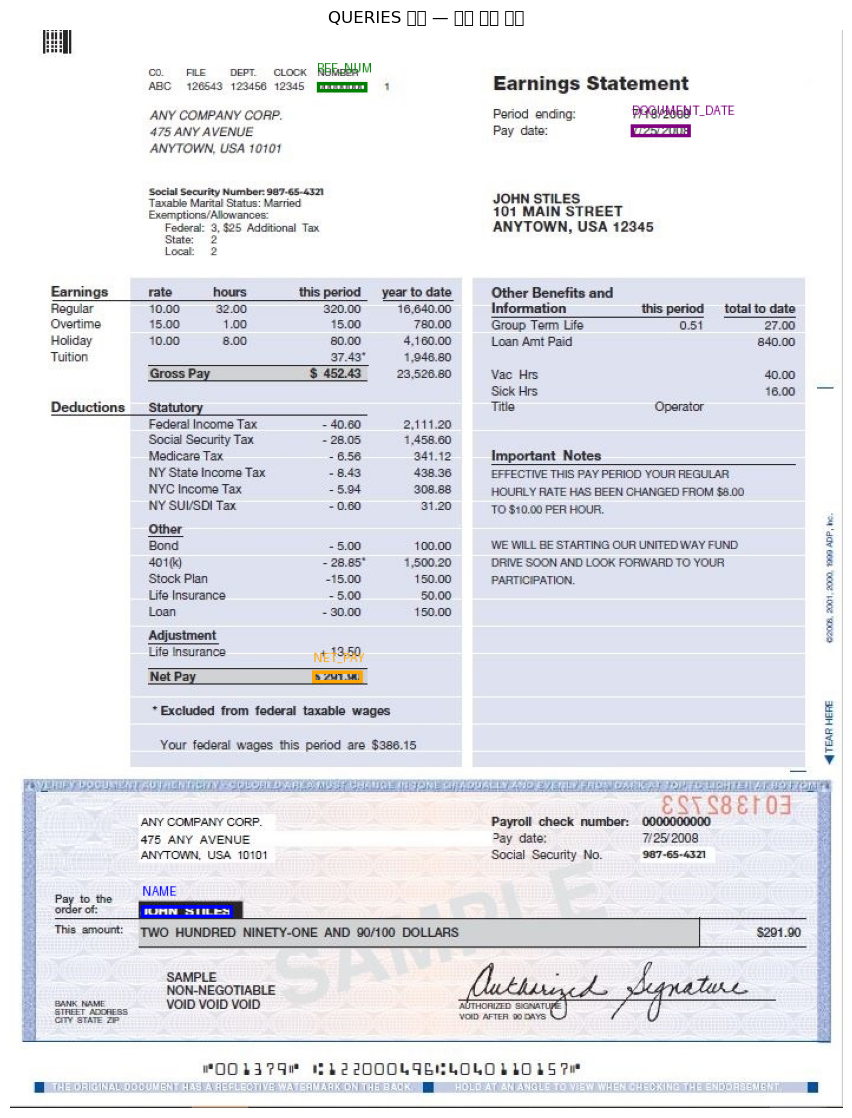

In [12]:
# ✏️ TODO 4: 답변 위치를 이미지에 표시하세요
from PIL import Image, ImageDraw

img = Image.open(image_path).convert('RGB')
draw = ImageDraw.Draw(img)
w, h = img.size

colors = ['purple', 'blue', 'green', 'orange', 'red', 'cyan']

for i, (qblock) in enumerate(query_blocks):
    alias = qblock.get('Query', {}).get('Alias', f'Q{i+1}')
    color = colors[i % len(colors)]
    
    for rel in qblock.get('Relationships', []):
        if rel['Type'] == 'ANSWER':
            for result_id in rel['Ids']:
                result_block = block_map.get(result_id)
                if result_block and 'Geometry' in result_block:
                    box = result_block['Geometry']['BoundingBox']     # ← 'BoundingBox'
                    left   = box['Left']  * w
                    top    = box['Top']   * h
                    right  = left + box['Width']  * w
                    bottom = top  + box['Height'] * h
                    draw.rectangle([left, top, right, bottom], outline=color, width=3)
                    draw.text((left, max(0, top-18)), alias, fill=color)

plt.figure(figsize=(12, 14))
plt.imshow(img)
plt.axis('off')
plt.title('QUERIES 결과 — 답변 위치 표시')
plt.show()


## ✏️ TODO 5: 신뢰도 낮은 답변 처리

신뢰도가 80% 미만인 답변에 대해 경고를 출력하는 검증 로직을 작성하세요.


In [13]:
# ✏️ TODO 5: 신뢰도 기반 답변 검증 로직을 작성하세요
CONFIDENCE_THRESHOLD = 80.0

print("📊 답변 신뢰도 검증 결과:")
print("-" * 50)
for alias, info in results.items():
    conf = info['confidence']                              # ← 'confidence'
    ans  = info['answer']                              # ← 'answer'
    
    if conf >= CONFIDENCE_THRESHOLD:                               # ← CONFIDENCE_THRESHOLD
        status = "✅"
    elif conf > 0:
        status = "⚠️  (낮은 신뢰도 — 수동 확인 권장)"
    else:
        status = "❌ (답변 없음)"
    
    print(f"  {alias}: '{ans}' [{conf:.1f}%] {status}")


📊 답변 신뢰도 검증 결과:
--------------------------------------------------
  DOCUMENT_DATE: '7/25/2008' [98.0%] ✅
  NAME: 'JOHN STILES' [96.0%] ✅
  REF_NUM: '00000000' [90.0%] ✅
  NET_PAY: '$291.90' [93.0%] ✅


## 💡 심화 도전
1. 같은 문서에 FORMS + QUERIES를 동시에 사용하고 결과를 비교해보세요.
2. 날짜 형식 답변(예: '2024-01-15')을 Python datetime 객체로 파싱해보세요.
3. 여러 문서에 동일한 쿼리 세트를 적용하여 일괄 처리하는 코드를 작성해보세요.
